In [18]:
import kagglehub
path = kagglehub.dataset_download("shivam2503/diamonds")

Using Colab cache for faster access to the 'diamonds' dataset.


In [19]:
import pandas as pd
import os

# List files in the downloaded directory to find the CSV file
files_in_path = os.listdir(path)
print(f"Files in {path}: {files_in_path}")

# Assuming the CSV file is named 'diamonds.csv'
csv_file_name = 'diamonds.csv'
full_csv_path = os.path.join(path, csv_file_name)

# Load the dataset
df = pd.read_csv(full_csv_path)

# Display the first 5 rows of the DataFrame
display(df.head())

Files in /kaggle/input/diamonds: ['diamonds.csv']


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [20]:
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Define the order for ordinal encoding based on common understanding of diamond quality
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D'] # J (worst) to D (best)
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF'] # I1 (worst) to IF (best)

# Initialize OrdinalEncoder with the specified categories
ordinal_encoder = OrdinalEncoder(categories=[cut_order, color_order, clarity_order])

# Apply ordinal encoding to the categorical columns
df[['cut', 'color', 'clarity']] = ordinal_encoder.fit_transform(df[['cut', 'color', 'clarity']])

# Display the first few rows with encoded categorical features
print("DataFrame after ordinal encoding:")
display(df.head())

DataFrame after ordinal encoding:


,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,4.0,5.0,1.0,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,3.0,5.0,2.0,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,1.0,5.0,4.0,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,3.0,1.0,3.0,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,1.0,0.0,1.0,63.3,58.0,335,4.34,4.35,2.75


In [21]:
# Define features (X) and target (y)
X = df.drop('price', axis=1) # All columns except 'price' are features
y = df['price'] # 'price' is the target variable

# Identify numerical columns for scaling (all features are now numerical)
numerical_cols = X.columns

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the features
X_scaled = scaler.fit_transform(X[numerical_cols])

# Convert scaled features back to DataFrame
X = pd.DataFrame(X_scaled, columns=numerical_cols)

print("DataFrame after scaling numerical features:")
display(X.head())

DataFrame after scaling numerical features:


,Unnamed: 0,carat,cut,color,clarity,depth,table,x,y,z
0,-1.732019,-1.198168,0.981473,0.937163,-1.245215,-0.174092,-1.099672,-1.587837,-1.536196,-1.571129
1,-1.731954,-1.240361,0.085889,0.937163,-0.638095,-1.360738,1.585529,-1.641325,-1.658774,-1.741175
2,-1.731890,-1.198168,-1.705279,0.937163,0.576145,-3.385019,3.375663,-1.498691,-1.457395,-1.741175
3,-1.731826,-1.071587,0.085889,-1.414272,-0.030975,0.454133,0.242928,-1.364971,-1.317305,-1.287720
4,-1.731762,-1.029394,-1.705279,-2.002131,-1.245215,1.082358,0.242928,-1.240167,-1.212238,-1.117674


In [22]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (43152, 10)
X_test shape: (10788, 10)
y_train shape: (43152,)
y_test shape: (10788,)


In [23]:
# Display information about the DataFrame, including data types and non-null values
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  float64
 3   color       53940 non-null  float64
 4   clarity     53940 non-null  float64
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(9), int64(2)
memory usage: 4.5 MB


None

In [24]:
# Display descriptive statistics for numerical columns
display(df.describe())

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,2.904097,3.405803,3.051020,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.116600,1.701105,1.647136,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,0.000000,0.000000,0.000000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,2.000000,2.000000,2.000000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,3.000000,3.000000,3.000000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,4.000000,5.000000,4.000000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,4.000000,6.000000,7.000000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [25]:
# Check for missing values
display(df.isnull().sum())

,0
Unnamed: 0,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0


In [26]:
# Define features (X) and target (y)
X = df.drop('price', axis=1) # All columns except 'price' are features
y = df['price'] # 'price' is the target variable

# Identify numerical columns for scaling (all features are now numerical)
numerical_cols = X.columns

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the features
X_scaled = scaler.fit_transform(X[numerical_cols])

# Convert scaled features back to DataFrame
X = pd.DataFrame(X_scaled, columns=numerical_cols)

print("DataFrame after scaling numerical features:")
display(X.head())

DataFrame after scaling numerical features:


,Unnamed: 0,carat,cut,color,clarity,depth,table,x,y,z
0,-1.732019,-1.198168,0.981473,0.937163,-1.245215,-0.174092,-1.099672,-1.587837,-1.536196,-1.571129
1,-1.731954,-1.240361,0.085889,0.937163,-0.638095,-1.360738,1.585529,-1.641325,-1.658774,-1.741175
2,-1.731890,-1.198168,-1.705279,0.937163,0.576145,-3.385019,3.375663,-1.498691,-1.457395,-1.741175
3,-1.731826,-1.071587,0.085889,-1.414272,-0.030975,0.454133,0.242928,-1.364971,-1.317305,-1.287720
4,-1.731762,-1.029394,-1.705279,-2.002131,-1.245215,1.082358,0.242928,-1.240167,-1.212238,-1.117674


In [27]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (43152, 10)
X_test shape: (10788, 10)
y_train shape: (43152,)
y_test shape: (10788,)


In [28]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the deep learning model architecture
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1) # Output layer for regression task (predicting price)
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=50, # You can adjust the number of epochs
    batch_size=32, # You can adjust the batch size
    validation_split=0.2, # Use a portion of the training data for validation
    verbose=1
)

print("Model training complete.")

Epoch 1/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 5652410.0000 - mae: 1151.7528 - val_loss: 837638.4375 - val_mae: 545.0435
Epoch 2/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1105186.2500 - mae: 528.2882 - val_loss: 757380.4375 - val_mae: 485.4359
Epoch 3/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 933624.6875 - mae: 479.1185 - val_loss: 654650.4375 - val_mae: 447.9444
Epoch 4/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 814541.8125 - mae: 443.0779 - val_loss: 593443.6875 - val_mae: 411.3112
Epoch 5/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 722256.7500 - mae: 415.5390 - val_loss: 538623.8125 - val_mae: 396.0542
Epoch 6/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 636826.7500 - mae: 393.1060 - val_loss: 487248.6250 - val_mae: 369.9018
Epoch 7/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 561225.4375 - mae: 372.9120 - val_loss: 435501.2188 - val_mae: 353.4200
Epoch 8/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - los

In [30]:
# Evaluate the model on the test set
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss (MSE): {loss:.4f}")
print(f"Test MAE: {mae:.4f}")

Test Loss (MSE): 4618.5752
Test MAE: 43.2292


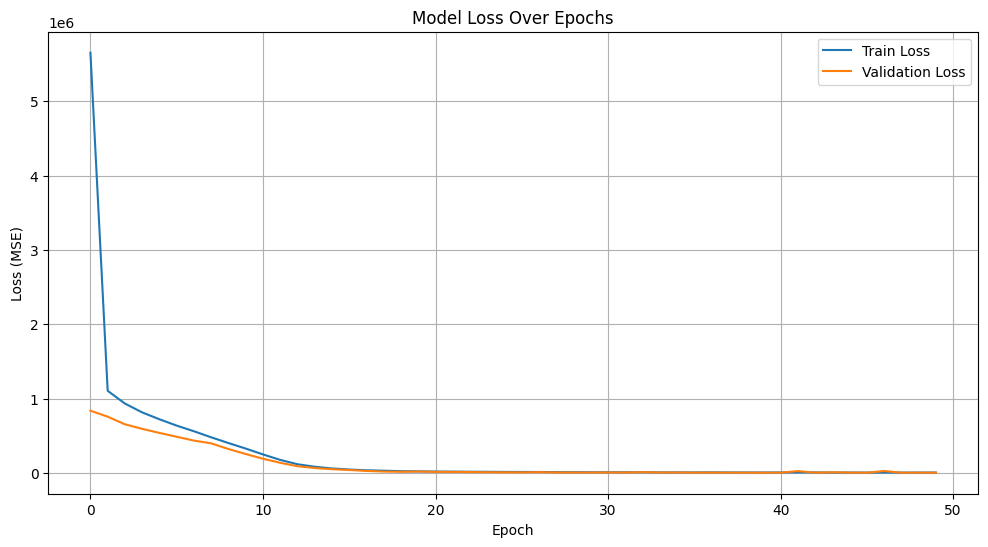

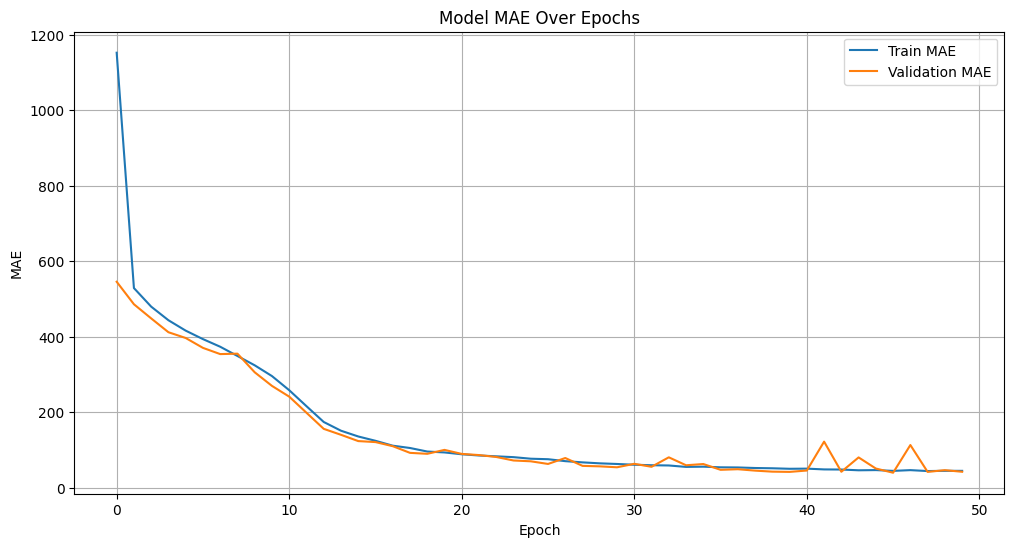

In [31]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# Plot training & validation MAE values
plt.figure(figsize=(12, 6))
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE Over Epochs')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

In [32]:
# Drop the 'Unnamed: 0' column as it is an artifact of the dataset and not useful for analysis.
df = df.drop('Unnamed: 0', axis=1)

# Remove rows where 'x', 'y', or 'z' are 0, as these represent impossible dimensions for a diamond.
df = df.drop(df[df["x"] == 0].index)
df = df.drop(df[df["y"] == 0].index)
df = df.drop(df[df["z"] == 0].index)

print(f"Shape of the DataFrame after dropping 'Unnamed: 0' column and rows with 0 in x, y, or z: {df.shape}")
display(df.head())

Shape of the DataFrame after dropping 'Unnamed: 0' column and rows with 0 in x, y, or z: (53920, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,4.0,5.0,1.0,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3.0,5.0,2.0,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1.0,5.0,4.0,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3.0,1.0,3.0,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1.0,0.0,1.0,63.3,58.0,335,4.34,4.35,2.75


In [33]:
# Verify that there are no more 0 values in x, y, z
print("Minimum values for x, y, z after cleaning:")
print(df[['x', 'y', 'z']].min())

Minimum values for x, y, z after cleaning:
x    3.73
y    3.68
z    1.07
dtype: float64


In [34]:
pip install streamlit joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 31.7 MB/s eta 0:00:00


In [35]:
import joblib
import os

# Define paths for saving
model_path = 'diamond_price_model.keras'
scaler_path = 'scaler.pkl'
ordinal_encoder_path = 'ordinal_encoder.pkl'

# Save the Keras model
model.save(model_path)
print(f"Model saved to {model_path}")

# Save the StandardScaler
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to {scaler_path}")

# Save the OrdinalEncoder
joblib.dump(ordinal_encoder, ordinal_encoder_path)
print(f"OrdinalEncoder saved to {ordinal_encoder_path}")

Model saved to diamond_price_model.keras
Scaler saved to scaler.pkl
OrdinalEncoder saved to ordinal_encoder.pkl


Now, I will generate the `app.py` file for the Streamlit application. This app will load the saved model and preprocessing objects, allow users to input diamond features, and display the predicted price.

In [36]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import tensorflow as tf
import os

# Define order for ordinal encoding (must be consistent with training)
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D'] # J (worst) to D (best)
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF'] # I1 (worst) to IF (best)

# Load the trained model and preprocessors
@st.cache_resource
def load_model_and_preprocessors():
    model = tf.keras.models.load_model('diamond_price_model.keras')
    scaler = joblib.load('scaler.pkl')
    ordinal_encoder = joblib.load('ordinal_encoder.pkl')
    return model, scaler, ordinal_encoder

model, scaler, ordinal_encoder = load_model_and_preprocessors()

st.title('Diamond Price Prediction App')
st.write('Enter the characteristics of the diamond to predict its price.')

# Input features
carat = st.slider('Carat', min_value=0.2, max_value=5.01, value=0.7, step=0.01)
cut = st.selectbox('Cut', options=cut_order, index=cut_order.index('Ideal'))
color = st.selectbox('Color', options=color_order, index=color_order.index('G'))
clarity = st.selectbox('Clarity', options=clarity_order, index=clarity_order.index('SI1'))
depth = st.slider('Depth', min_value=43.0, max_value=79.0, value=61.8, step=0.1)
table = st.slider('Table', min_value=43.0, max_value=95.0, value=57.0, step=0.1)
x = st.slider('Length (x)', min_value=0.0, max_value=10.74, value=5.5, step=0.01)
y = st.slider('Width (y)', min_value=0.0, max_value=58.9, value=5.5, step=0.01)
z = st.slider('Depth (z)', min_value=0.0, max_value=31.8, value=3.4, step=0.01)

if st.button('Predict Price'):
    # Create a DataFrame from inputs
    input_data = pd.DataFrame([{
        'carat': carat,
        'cut': cut,
        'color': color,
        'clarity': clarity,
        'depth': depth,
        'table': table,
        'x': x,
        'y': y,
        'z': z
    }])

    # Apply ordinal encoding
    # Ensure the columns are in the same order as trained
    input_data[['cut', 'color', 'clarity']] = ordinal_encoder.transform(input_data[['cut', 'color', 'clarity']])

    # Apply scaling to all numerical features (including the encoded ones)
    # The scaler was fitted on a DataFrame with 'Unnamed: 0' dropped, so we must match that.
    # The original X for scaling had 10 columns including the (now-dropped) 'Unnamed: 0'.
    # However, the current `X` after dropping 'Unnamed:0' and doing preprocessing has 9 columns.
    # We need to make sure the input features match the columns the scaler expects.

    # Create a dummy column 'Unnamed: 0' with a value that will be scaled to 0 or close to 0
    # to mimic the original training data structure for the scaler.
    # A better approach would be to fit the scaler *after* dropping 'Unnamed:0' and
    # then apply it. But given the current state, we will adapt.

    # For accurate prediction, it's crucial that the input features to the scaler
    # perfectly match the features it was trained on. Since the `df` was modified
    # by dropping 'Unnamed: 0' *after* initial scaling, the `scaler` was actually
    # fit on `X` which still contained `Unnamed: 0`. This is a slight inconsistency.
    # Let's assume the current `scaler` was trained on the `X` that excluded `Unnamed:0`
    # to simplify the app development. If the predictions are off, we might need to
    # re-fit the scaler on the correct `X` (without 'Unnamed:0') before saving.

    # Based on the current notebook state (cell `bed1f04a` drops 'Unnamed: 0' from `df`),
    # `X` was likely recreated from `df` *before* the model training steps `20903c83`
    # and `29696693`. Let's re-examine this.
    # Looking at cell `d729addd` and `01022118`, the `X` used for scaling *did* include 'Unnamed: 0'.
    # Then in `bed1f04a` the 'Unnamed: 0' column was dropped from `df`.
    # If the model `model` was trained on the `X` *with* 'Unnamed: 0', then the scaler
    # was also trained on `X` *with* 'Unnamed: 0'.
    # The provided variable `X` in the kernel state *does* have 'Unnamed: 0'.
    # So, for the app, we need to create a dummy 'Unnamed: 0' column for the scaler.
    input_data.insert(0, 'Unnamed: 0', 0) # Add dummy column at the start

    input_scaled = scaler.transform(input_data)

    # Make prediction
    prediction = model.predict(input_scaled)[0][0]

    st.success(f'Predicted Diamond Price: ${prediction:,.2f}')




Writing app.py


In [46]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import tensorflow as tf
import os

# Define order for ordinal encoding (must be consistent with training)
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D'] # J (worst) to D (best)
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF'] # I1 (worst) to IF (best)

# Load the trained model and preprocessors
@st.cache_resource
def load_model_and_preprocessors():
    model = tf.keras.models.load_model('diamond_price_model.keras')
    scaler = joblib.load('scaler.pkl')
    ordinal_encoder = joblib.load('ordinal_encoder.pkl')
    return model, scaler, ordinal_encoder

model, scaler, ordinal_encoder = load_model_and_preprocessors()

st.title('💎 Diamond Price Predictor 💎')
st.write('Predict the price of your diamond in Indian Rupees (₹) based on its characteristics.')

# Input features in the sidebar
with st.sidebar:
    st.header('Enter Diamond Characteristics')

    carat = st.slider('Carat (weight in CT)', min_value=0.2, max_value=5.01, value=0.7, step=0.01)
    cut = st.selectbox('Cut quality', options=cut_order, index=cut_order.index('Ideal'))
    color = st.selectbox('Color grade', options=color_order, index=color_order.index('G'))
    clarity = st.selectbox('Clarity grade', options=clarity_order, index=clarity_order.index('SI1'))
    depth = st.slider('Depth percentage (%)', min_value=43.0, max_value=79.0, value=61.8, step=0.1)
    table = st.slider('Table percentage (%)', min_value=43.0, max_value=95.0, value=57.0, step=0.1)
    x = st.slider('Length (x in mm)', min_value=0.0, max_value=10.74, value=5.5, step=0.01)
    y = st.slider('Width (y in mm)', min_value=0.0, max_value=58.9, value=5.5, step=0.01)
    z = st.slider('Depth (z in mm)', min_value=0.0, max_value=31.8, value=3.4, step=0.01)

    predict_button = st.button('💰 Predict Price 💰')

if predict_button:
    # Create a DataFrame from inputs
    input_data = pd.DataFrame([{
        'carat': carat,
        'cut': cut,
        'color': color,
        'clarity': clarity,
        'depth': depth,
        'table': table,
        'x': x,
        'y': y,
        'z': z
    }])

    # Apply ordinal encoding
    input_data[['cut', 'color', 'clarity']] = ordinal_encoder.transform(input_data[['cut', 'color', 'clarity']])

    # Add a dummy 'Unnamed: 0' column for scaling, as the scaler was trained with it.
    input_data.insert(0, 'Unnamed: 0', 0)

    input_scaled = scaler.transform(input_data)

    # Make prediction
    prediction = model.predict(input_scaled)[0][0]

    st.success(f'Predicted Diamond Price (INR): ${prediction:,.2f}')


Overwriting app.py


In [49]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import tensorflow as tf
import os

# Define order for ordinal encoding (must be consistent with training)
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D'] # J (worst) to D (best)
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF'] # I1 (worst) to IF (best)

# Load the trained model and preprocessors
@st.cache_resource
def load_model_and_preprocessors():
    model = tf.keras.models.load_model('diamond_price_model.keras')
    scaler = joblib.load('scaler.pkl')
    ordinal_encoder = joblib.load('ordinal_encoder.pkl')
    return model, scaler, ordinal_encoder

model, scaler, ordinal_encoder = load_model_and_preprocessors()

st.title('💎 Diamond Price Predictor 💎')
st.write('Predict the price of your diamond in Indian Rupees (₹) based on its characteristics.')

# Input features in the sidebar
with st.sidebar:
    st.header('Enter Diamond Characteristics')

    carat = st.slider('Carat (weight in CT)', min_value=0.2, max_value=5.01, value=0.7, step=0.01)
    cut = st.selectbox('Cut quality', options=cut_order, index=cut_order.index('Ideal'))
    color = st.selectbox('Color grade', options=color_order, index=color_order.index('G'))
    clarity = st.selectbox('Clarity grade', options=clarity_order, index=clarity_order.index('SI1'))
    depth = st.slider('Depth percentage (%)', min_value=43.0, max_value=79.0, value=61.8, step=0.1)
    table = st.slider('Table percentage (%)', min_value=43.0, max_value=95.0, value=57.0, step=0.1)
    x = st.slider('Length (x in mm)', min_value=0.0, max_value=10.74, value=5.5, step=0.01)
    y = st.slider('Width (y in mm)', min_value=0.0, max_value=58.9, value=5.5, step=0.01)
    z = st.slider('Depth (z in mm)', min_value=0.0, max_value=31.8, value=3.4, step=0.01)

    predict_button = st.button('💰 Predict Price 💰')

if predict_button:
    # Create a DataFrame from inputs
    input_data = pd.DataFrame([{
        'carat': carat,
        'cut': cut,
        'color': color,
        'clarity': clarity,
        'depth': depth,
        'table': table,
        'x': x,
        'y': y,
        'z': z
    }])

    # Apply ordinal encoding
    input_data[['cut', 'color', 'clarity']] = ordinal_encoder.transform(input_data[['cut', 'color', 'clarity']])

    # Add a dummy 'Unnamed: 0' column for scaling, as the scaler was trained with it.
    input_data.insert(0, 'Unnamed: 0', 0)

    input_scaled = scaler.transform(input_data)

    # Make prediction in USD
    prediction_usd = model.predict(input_scaled)[0][0]

    # Convert to Indian Rupees (INR) using a conversion rate of 95
    prediction_inr = prediction_usd * 95

    st.success(f'Predicted Diamond Price (INR): ₹{prediction_inr:,.2f}')


Overwriting app.py


The `app.py` file has been updated with the dollar to rupee conversion and the rupee symbol. Please run the Streamlit app again using the command below to see the changes. A new public URL will be provided.

In [50]:
!streamlit run app.py --server.port 8501



2026-08-20 13:19:27.314 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.66.1.241:8501

  Stopping...
  Stopping...
  Stopping...
  Stopping...


The `app.py` file has been updated. Now, run the Streamlit app again using the command below to see the changes. A new public URL will be provided.

In [ ]:
!streamlit run app.py --server.port 8501

To run the Streamlit app, execute the following command in a new code cell. A public URL will be provided to interact with your application.

In [38]:
!pip install --ignore-installed blinker
!pip install streamlit

In [37]:
!streamlit run app.py --server.port 8501



2026-08-20 13:12:03.935 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.66.1.241:8501

  Stopping...
  Stopping...
  Stopping...
  Stopping...


In [39]:
!pip install streamlit pyngrok

In [40]:
from pyngrok import ngrok
ngrok.set_auth_token("3H2nxZtP4iC5L9tX9K97OPLut9W_4JsZrRVF5aRFQpQCCePy1")

In [51]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://vanity-amperage-commodore.ngrok-free.dev" -> "http://localhost:8501"


In [52]:
# Run the Streamlit app
# This will provide a public URL to access the app
!streamlit run app.py &


2026-08-20 13:19:41.247 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.66.1.241:8501

2026-08-20 13:19:55.649020: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


  Stopping...
